# Sobel

In [126]:
import os
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision.io import read_image, ImageReadMode

FIGURES_DIR = "figures"

if not os.path.exists(FIGURES_DIR):
    os.makedirs(FIGURES_DIR)

In [127]:
def save_plot(fig, filename):
    fig_file_path = os.path.join(FIGURES_DIR, filename)
    fig.savefig(fig_file_path, dpi=300)

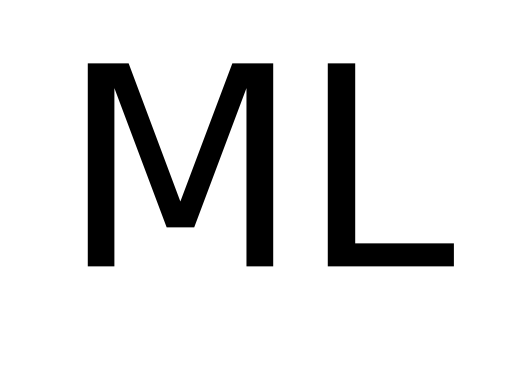

In [128]:
text = "ML"
ml_file = "ml.png"
fig, ax = plt.subplots()
ax.axis('off')
plt.text(0.5, 0.5, text, size=200, ha="center", va="center")
save_plot(fig, ml_file)

In [129]:
image = read_image(os.path.join(FIGURES_DIR, "ml.png"), mode=ImageReadMode.GRAY).type(
    torch.FloatTensor  # pyright: ignore
)
x = image.unsqueeze(0)

In [130]:
# fmt: off
Kx = torch.tensor([[1., 0., -1.],
                   [2., 0., -2.],
                   [1., 0., -1.]])
Ky = torch.tensor([[ 1.,  2.,  1.],
                   [ 0.,  0.,  0.],
                   [-1., -2., -1.]])
# fmt: on

K = torch.stack([Kx, Ky]).unsqueeze(1)
K = torch.flip(K, dims=[-2, -1])

In [131]:
conv = nn.Conv2d(1, 2, kernel_size=3, padding=1, bias=False)
conv.weight = nn.Parameter(K, requires_grad=False)

g = conv(x)
G = torch.sqrt(torch.sum(torch.square(g), dim=1))

Gx, Gy = g[0, 0], g[0, 1]

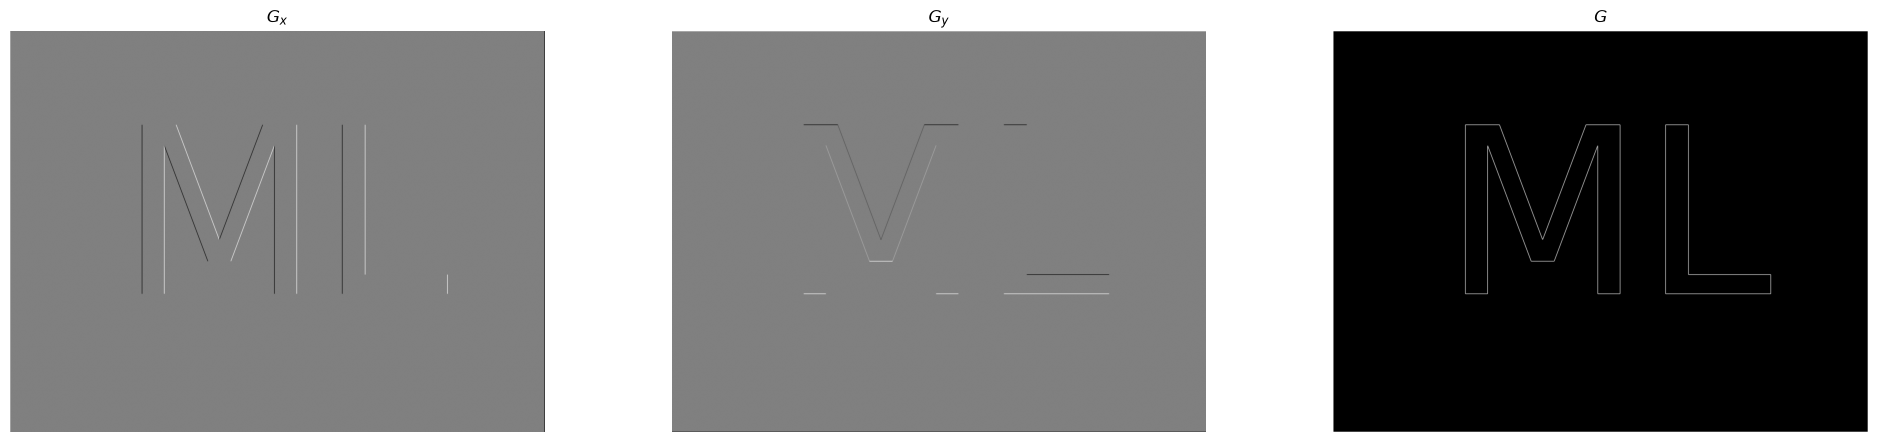

In [132]:
fig, [ax0, ax1, ax2] = plt.subplots(1, 3, figsize=(20, 4.5))

ax0.imshow(Gx, cmap="gray")
ax0.set_title("$G_x$")
ax0.axis("off")

ax1.imshow(Gy, cmap="gray")
ax1.set_title("$G_y$")
ax1.axis("off")


ax2.imshow(G[0], cmap="gray")
ax2.set_title("$G$")
ax2.axis("off")

plt.tight_layout()
plt.show()
save_plot(fig, "sobel.png")